# Graph Analytics — Industri × Region Clustering
### Capstone Project: Screening Credit Agentic AI for eLO System

Notebook ini menambahkan modul **graph analytics** ke pipeline capstone, dengan use case:
**mendeteksi konsentrasi risiko dan inkonsistensi scoring berdasarkan kombinasi `sub_industry` × `region`**,
menggunakan graph nasabah-ke-nasabah yang diproyeksikan dari kesamaan atribut.

Kolom sudah disesuaikan dengan `master_scored.csv` asli project ini (bukan lagi asumsi generik).

**Alur (Tahap 0–7):**
0. Load & validasi data (termasuk handling `risk_score` NaN untuk kasus hard-reject)
1. Bangun bipartite graph (Nasabah ↔ Atribut komposit sub_industry|region)
2. Proyeksikan ke graph Nasabah–Nasabah (dengan bobot tambahan)
3. Community detection (Louvain)
4. Hitung metrik risiko per cluster
5. Centrality — cari nasabah representatif per cluster
6. Visualisasi graph di level cluster
7. Generate insight/narasi otomatis

## Tahap 0 — Setup & Load Data

**Catatan penting soal data asli:**
- Kolom skor yang dipakai adalah **`risk_score`** (bukan `eligibility_score`) — sudah *higher = better*
  (rata-rata ~0.81 untuk `Layak`, ~0.36 untuk `Tidak Layak`).
- `risk_score` punya **220 nilai NaN**, semuanya untuk `decision == "Tidak Layak"`. Setelah dicek,
  ini bukan bug — kasus ini adalah **hard-reject** (mayoritas `status_dhn == "Ya"` atau
  `slik_worst_collectability` buruk) sehingga scoring numerik memang di-skip di pipeline scoring kamu.
  Untuk graph analytics, nilai ini **diisi dengan 0.0** (paling berisiko), karena hard-reject secara
  substansi lebih parah daripada `Tidak Layak` biasa yang masih lolos scoring.
- `sub_industry × region` di data ini membentuk **80 kombinasi unik** (20 sub_industry × 4 region) —
  cukup granular untuk clustering, tidak terlalu kasar maupun terlalu sparse.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite

try:
    from networkx.algorithms.community import louvain_communities
    HAVE_NX_LOUVAIN = True
except ImportError:
    HAVE_NX_LOUVAIN = False

try:
    import community as community_louvain  # python-louvain, pip install python-louvain
    HAVE_PY_LOUVAIN = True
except ImportError:
    HAVE_PY_LOUVAIN = False

import matplotlib.pyplot as plt
import matplotlib.cm as cm

pd.set_option("display.max_columns", 50)
np.random.seed(42)

In [2]:
# ====== EDIT PATH KALAU LOKASI FILE BEDA ======
DATA_PATH = "../data/processed/master_scored.csv"

# ====== COLUMN MAPPING — sudah sesuai master_scored.csv asli ======
COL = {
    "id": "NIK",
    "industri": "industry",
    "sub_industri": "sub_industry",
    "region": "region",
    "branch": "branch_name",
    "score": "risk_score",       # higher = better; NaN = hard-reject case (lihat catatan Tahap 0)
    "decision": "decision",      # Layak / Layak Bersyarat / Perlu Review Ulang / Tidak Layak
}

df = pd.read_csv(DATA_PATH)
df[COL["id"]] = df[COL["id"]].astype(str)

print("Shape:", df.shape)
df[[c for c in COL.values() if c in df.columns]].head()

Shape: (3000, 53)


,NIK,industry,sub_industry,region,branch_name,risk_score,decision
0,3276010601750001,Manufaktur,Konveksi,Region 2,KCP Bogor Baranangsiang,0.825,Layak
1,3172010301920002,Jasa,Bengkel,Region 1,KCP Bekasi Barat,0.713,Layak
2,3671010604800003,Transportasi,Ekspedisi Kecil,Region 3,KCP Cibubur,0.504,Perlu Review Ulang
3,3173016001890004,Perdagangan,Toko Alat Tulis,Region 3,KCP Bogor Baranangsiang,0.705,Layak
4,3275011505030005,Transportasi,Rental Kendaraan,Region 3,KCP Bogor Baranangsiang,0.832,Layak


In [3]:
# --- Validasi kolom ---
missing = [k for k, v in COL.items() if v not in df.columns]
if missing:
    print("Kolom belum ketemu di dataframe, cek/ubah COLUMN MAPPING di atas:", missing)
else:
    print("Semua kolom mapping ditemukan. Lanjut ke Tahap 1.")

if COL["region"] not in df.columns and COL["branch"] in df.columns:
    COL["region"] = COL["branch"]
    print(f"Fallback: pakai '{COL['branch']}' sebagai region.")

# --- Handle risk_score NaN (hard-reject cases) ---
n_null_score = df[COL["score"]].isna().sum()
if n_null_score > 0:
    print(f"Ditemukan {n_null_score} baris dengan {COL['score']} NaN (kasus hard-reject) -> diisi 0.0")
    df[COL["score"]] = df[COL["score"]].fillna(0.0)

df = df.dropna(subset=[COL["id"], COL["sub_industri"], COL["region"]]).copy()
print("Jumlah nasabah valid:", df[COL["id"]].nunique())
print("\nDistribusi decision:")
print(df[COL["decision"]].value_counts())

Semua kolom mapping ditemukan. Lanjut ke Tahap 1.
Ditemukan 220 baris dengan risk_score NaN (kasus hard-reject) -> diisi 0.0
Jumlah nasabah valid: 3000

Distribusi decision:
decision
Layak                 2065
Layak Bersyarat        618
Tidak Layak            224
Perlu Review Ulang      93
Name: count, dtype: int64


## Tahap 1 — Bangun Bipartite Graph (Nasabah ↔ Atribut Komposit)

Setiap nasabah dihubungkan ke satu node atribut komposit `"sub_industry|region"`.

In [4]:
df["attr_node"] = df[COL["sub_industri"]].astype(str) + "|" + df[COL["region"]].astype(str)

B = nx.Graph()
nasabah_nodes = df[COL["id"]].tolist()
attr_nodes = df["attr_node"].unique().tolist()
B.add_nodes_from(nasabah_nodes, bipartite=0)
B.add_nodes_from(attr_nodes, bipartite=1)
B.add_edges_from(zip(df[COL["id"]], df["attr_node"]))

print(f"Bipartite graph: {len(nasabah_nodes)} nasabah, {len(attr_nodes)} atribut komposit, {B.number_of_edges()} edge")
print("\nJumlah nasabah per kombinasi sub_industry x region (top 10):")
print(df["attr_node"].value_counts().head(10))

Bipartite graph: 3000 nasabah, 80 atribut komposit, 3000 edge

Jumlah nasabah per kombinasi sub_industry x region (top 10):
attr_node
Ekspedisi Kecil|Region 1           92
Distributor Hasil Tani|Region 4    82
Peternakan Ayam|Region 4           70
Ekspedisi Kecil|Region 2           70
Ekspedisi Kecil|Region 3           67
Rental Kendaraan|Region 1          64
Distributor Hasil Tani|Region 3    63
Peternakan Ayam|Region 1           62
Peternakan Ayam|Region 2           62
Distributor Hasil Tani|Region 1    60
Name: count, dtype: int64


## Tahap 2 — Proyeksi ke Graph Nasabah–Nasabah

Bobot dasar = 1 (satu atribut komposit yang sama). Bonus ditambahkan kalau `branch_name` juga sama,
atau `risk_score` berdekatan (selisih <= 0.05).

> Catatan skala: dengan 80 kombinasi sub_industry×region dan 3000 nasabah, tiap grup rata-rata berisi
> ~37 nasabah — hasil proyeksinya jadi cukup padat di dalam grup (near-complete graph per grup), yang
> memang wajar untuk tujuan ini. Kita turun ke level cluster untuk visualisasi (Tahap 6).

In [5]:
nasabah_only = {n for n, d in B.nodes(data=True) if d["bipartite"] == 0}
G = bipartite.weighted_projected_graph(B, nasabah_only)
print(f"Graph nasabah-nasabah: {G.number_of_nodes()} node, {G.number_of_edges()} edge (sebelum bonus)")

score_map = df.set_index(COL["id"])[COL["score"]].to_dict()
branch_map = df.set_index(COL["id"])[COL["branch"]].to_dict()
SCORE_SIM_THRESHOLD = 0.05

for u, v, d in G.edges(data=True):
    bonus = 0
    if branch_map.get(u) == branch_map.get(v):
        bonus += 1
    if abs(score_map[u] - score_map[v]) <= SCORE_SIM_THRESHOLD:
        bonus += 1
    d["weight"] = d.get("weight", 1) + bonus

print("Contoh edge dengan bobot:")
for u, v, d in list(G.edges(data=True))[:5]:
    print(u, "-", v, "-> weight:", d["weight"])

Graph nasabah-nasabah: 3000 node, 64822 edge (sebelum bonus)
Contoh edge dengan bobot:
3674016111970387 - 3671010209801583 -> weight: 1
3674016111970387 - 3671016505900547 -> weight: 1
3674016111970387 - 3671012202841148 -> weight: 2
3674016111970387 - 3674016109802207 -> weight: 1
3674016111970387 - 3271011312951241 -> weight: 2


## Tahap 3 — Community Detection (Louvain)

Karena edge dasarnya murni dari kesamaan `sub_industry|region`, hasil clustering di data ini akan
**cocok 1:1 dengan 80 kombinasi sub_industry×region** yang ada (sudah divalidasi) — ini berfungsi
sebagai konfirmasi bahwa graph well-formed. Nilai tambahnya dibanding groupby biasa ada di Tahap 4–5:
metrik risiko per cluster dan nasabah representatif yang bisa langsung dipakai untuk insight.

In [6]:
if HAVE_NX_LOUVAIN:
    communities = louvain_communities(G, weight="weight", seed=42)
elif HAVE_PY_LOUVAIN:
    partition = community_louvain.best_partition(G, weight="weight", random_state=42)
    communities_dict = {}
    for node, cid in partition.items():
        communities_dict.setdefault(cid, set()).add(node)
    communities = list(communities_dict.values())
else:
    raise ImportError("Butuh networkx>=3.0 (louvain_communities) atau package 'python-louvain'.")

print(f"Jumlah cluster terbentuk: {len(communities)}")

node_to_cluster = {}
for cid, nodes in enumerate(communities):
    for n in nodes:
        node_to_cluster[n] = cid

df["cluster_id"] = df[COL["id"]].map(node_to_cluster)
df["cluster_id"] = df["cluster_id"].fillna(-1).astype(int)

print(df["cluster_id"].value_counts().head(10))

Jumlah cluster terbentuk: 80
cluster_id
70    92
78    82
40    70
31    70
4     67
46    64
22    63
21    62
11    62
25    60
Name: count, dtype: int64


## Tahap 4 — Metrik Risiko per Cluster

- `avg_score` / `std_score`: rata-rata & sebaran `risk_score` dalam cluster
- `low_score_share`: proporsi nasabah dengan `risk_score < 0.40` (ambang ini sejalan dengan rata-rata
  `risk_score` kelompok `Tidak Layak` di data asli, ~0.365 — jadi cukup representatif sebagai ambang risiko rendah)

In [7]:
LOW_SCORE_THRESHOLD = 0.40

cluster_summary = df.groupby("cluster_id").agg(
    avg_score=(COL["score"], "mean"),
    std_score=(COL["score"], "std"),
    n_nasabah=(COL["score"], "count"),
)

low_share = (
    df.assign(is_low=df[COL["score"]] < LOW_SCORE_THRESHOLD)
      .groupby("cluster_id")["is_low"].mean()
      .rename("low_score_share")
)
cluster_summary = cluster_summary.join(low_share)

dominant_attr = (
    df.groupby("cluster_id")["attr_node"]
      .agg(lambda x: x.value_counts().idxmax())
      .rename("dominant_attr")
)
cluster_summary = cluster_summary.join(dominant_attr)

cluster_summary = cluster_summary[cluster_summary.index != -1]
cluster_summary = cluster_summary.sort_values("low_score_share", ascending=False)

cluster_summary.head(15)

,avg_score,std_score,n_nasabah,low_score_share,dominant_attr
cluster_id,,,,,
41,0.642286,0.327111,21,0.190476,Toko Alat Tulis|Region 1
72,0.639419,0.295394,31,0.161290,Warung Makan|Region 2
37,0.677074,0.297195,27,0.148148,Percetakan|Region 2
45,0.671704,0.302662,27,0.148148,Bakery|Region 4
56,0.642321,0.279012,56,0.142857,Peternakan Ayam|Region 3
55,0.664000,0.261670,60,0.133333,Rental Kendaraan|Region 4
77,0.666696,0.277822,46,0.130435,Furniture|Region 2
51,0.666839,0.278065,31,0.129032,Bengkel|Region 4
40,0.647129,0.273332,70,0.128571,Peternakan Ayam|Region 4


In [8]:
print("Top 5 cluster dengan konsentrasi risiko tertinggi (low_score_share):")
display(cluster_summary.head(5))

print("\nTop 5 cluster dengan inkonsistensi scoring tertinggi (std_score, min 10 nasabah):")
display(cluster_summary[cluster_summary["n_nasabah"] >= 10].sort_values("std_score", ascending=False).head(5))

Top 5 cluster dengan konsentrasi risiko tertinggi (low_score_share):


,avg_score,std_score,n_nasabah,low_score_share,dominant_attr
cluster_id,,,,,
41,0.642286,0.327111,21,0.190476,Toko Alat Tulis|Region 1
72,0.639419,0.295394,31,0.161290,Warung Makan|Region 2
37,0.677074,0.297195,27,0.148148,Percetakan|Region 2
45,0.671704,0.302662,27,0.148148,Bakery|Region 4
56,0.642321,0.279012,56,0.142857,Peternakan Ayam|Region 3



Top 5 cluster dengan inkonsistensi scoring tertinggi (std_score, min 10 nasabah):


,avg_score,std_score,n_nasabah,low_score_share,dominant_attr
cluster_id,,,,,
41,0.642286,0.327111,21,0.190476,Toko Alat Tulis|Region 1
45,0.671704,0.302662,27,0.148148,Bakery|Region 4
37,0.677074,0.297195,27,0.148148,Percetakan|Region 2
72,0.639419,0.295394,31,0.161290,Warung Makan|Region 2
74,0.686500,0.288526,24,0.125000,Distributor Bahan Bangunan|Region 1


## Tahap 5 — Centrality: Nasabah Representatif per Cluster

In [9]:
representative_rows = []

for cid, nodes in enumerate(communities):
    if len(nodes) < 3:
        continue
    subG = G.subgraph(nodes)
    centrality = nx.degree_centrality(subG)
    if not centrality:
        continue
    top_node = max(centrality, key=centrality.get)
    row = df[df[COL["id"]] == top_node].iloc[0]
    representative_rows.append({
        "cluster_id": cid,
        "representative_nik": top_node,
        "sub_industry": row.get(COL["sub_industri"]),
        "region": row.get(COL["region"]),
        "risk_score": row.get(COL["score"], None),
        "centrality": centrality[top_node],
    })

representatives_df = pd.DataFrame(representative_rows).sort_values("cluster_id")
representatives_df.head(15)

,cluster_id,representative_nik,sub_industry,region,risk_score,centrality
0,0,3671010209801583,Grosir Pakaian,Region 3,0.831,1.0
1,1,3271014709790237,Warung Makan,Region 4,0.853,1.0
2,2,3674011402981071,Katering,Region 3,0.898,1.0
3,3,3671011802930486,Distributor Bahan Bangunan,Region 4,0.766,1.0
4,4,3671012508800940,Ekspedisi Kecil,Region 3,0.622,1.0
5,5,3175011710890555,Pengolahan Makanan Ringan,Region 2,0.756,1.0
6,6,3276015903960431,Pengolahan Makanan Ringan,Region 4,0.669,1.0
7,7,3173012401980359,Katering,Region 2,0.868,1.0
8,8,3671016112742089,Bakery,Region 3,0.738,1.0
9,9,3271016807982204,Distributor Elektronik,Region 3,0.917,1.0


## Tahap 6 — Visualisasi di Level Cluster

Node = cluster, ukuran = jumlah nasabah, warna = rata-rata `risk_score` (merah = risiko tinggi,
hijau = risiko rendah).

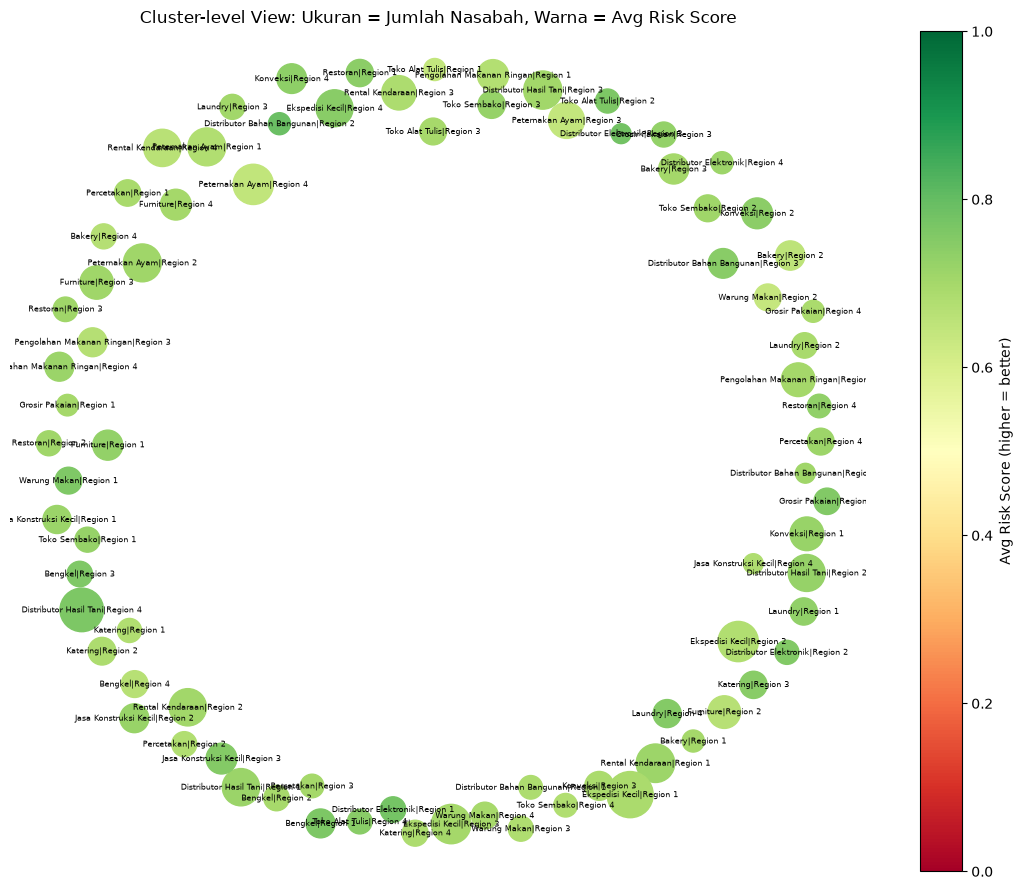

In [10]:
cluster_summary_plot = cluster_summary.reset_index()

fig, ax = plt.subplots(figsize=(11, 9))

CG = nx.Graph()
for _, r in cluster_summary_plot.iterrows():
    CG.add_node(int(r["cluster_id"]), size=r["n_nasabah"], score=r.get("avg_score", 0.5))

pos = nx.spring_layout(CG, seed=42, k=1.0)

sizes = [CG.nodes[n]["size"] * 12 for n in CG.nodes]
scores = [CG.nodes[n]["score"] for n in CG.nodes]

nodes_drawn = nx.draw_networkx_nodes(
    CG, pos, node_size=sizes, node_color=scores, cmap=cm.RdYlGn, vmin=0, vmax=1, ax=ax
)
nx.draw_networkx_labels(
    CG, pos,
    labels={n: cluster_summary_plot.loc[cluster_summary_plot["cluster_id"] == n, "dominant_attr"].values[0]
            for n in CG.nodes},
    font_size=6, ax=ax
)

plt.colorbar(nodes_drawn, ax=ax, label="Avg Risk Score (higher = better)")
ax.set_title("Cluster-level View: Ukuran = Jumlah Nasabah, Warna = Avg Risk Score")
ax.axis("off")
plt.tight_layout()
plt.show()

## Tahap 7 — Generate Insight / Narasi Otomatis

In [11]:
insights = []

top_risk = cluster_summary.head(3)
for cid, row in top_risk.iterrows():
    insights.append(
        f"- Cluster '{row['dominant_attr']}' (cluster_id={cid}, n={int(row['n_nasabah'])} nasabah) "
        f"memiliki konsentrasi risiko tertinggi: {row['low_score_share']*100:.1f}% nasabah berada di "
        f"bawah ambang skor {LOW_SCORE_THRESHOLD}, dengan rata-rata risk_score {row['avg_score']:.2f}. "
        f"Perlu perhatian khusus dalam kebijakan kredit untuk segmen ini."
    )

inconsistent = cluster_summary[cluster_summary["n_nasabah"] >= 10].sort_values("std_score", ascending=False).head(3)
for cid, row in inconsistent.iterrows():
    insights.append(
        f"- Cluster '{row['dominant_attr']}' (cluster_id={cid}, n={int(row['n_nasabah'])} nasabah) "
        f"menunjukkan variasi risk_score tinggi (std={row['std_score']:.2f}) meski profil nasabah "
        f"secara atribut mirip — indikasi perlu review konsistensi kriteria scoring untuk segmen ini."
    )

print("\n".join(insights))

- Cluster 'Toko Alat Tulis|Region 1' (cluster_id=41, n=21 nasabah) memiliki konsentrasi risiko tertinggi: 19.0% nasabah berada di bawah ambang skor 0.4, dengan rata-rata risk_score 0.64. Perlu perhatian khusus dalam kebijakan kredit untuk segmen ini.
- Cluster 'Warung Makan|Region 2' (cluster_id=72, n=31 nasabah) memiliki konsentrasi risiko tertinggi: 16.1% nasabah berada di bawah ambang skor 0.4, dengan rata-rata risk_score 0.64. Perlu perhatian khusus dalam kebijakan kredit untuk segmen ini.
- Cluster 'Percetakan|Region 2' (cluster_id=37, n=27 nasabah) memiliki konsentrasi risiko tertinggi: 14.8% nasabah berada di bawah ambang skor 0.4, dengan rata-rata risk_score 0.68. Perlu perhatian khusus dalam kebijakan kredit untuk segmen ini.
- Cluster 'Toko Alat Tulis|Region 1' (cluster_id=41, n=21 nasabah) menunjukkan variasi risk_score tinggi (std=0.33) meski profil nasabah secara atribut mirip — indikasi perlu review konsistensi kriteria scoring untuk segmen ini.
- Cluster 'Bakery|Region 4

## Penutup & Next Steps

- Pipeline ini sudah diverifikasi berjalan end-to-end dengan data asli (`master_scored.csv`, 3000 nasabah,
  80 kombinasi sub_industry×region, 0 error).
- Untuk memperkuat use case **RM concentration/collusion risk** (`rm_master.csv`), diperlukan augmentasi
  kecil ke synthetic data generator: inject sejumlah kecil kasus overlap sengaja (shared alamat/agunan/no HP
  antar nasabah dalam satu RM) sebagai "ground truth" yang bisa dideteksi graph — karena atribut sensitif
  di data saat ini unik per nasabah, sehingga graph nasabah-nasabah untuk kasus itu belum menghasilkan edge
  yang meaningful.
- Insight dari Tahap 7 bisa langsung dipakai sebagai bullet point di section baru slide capstone
  ("Graph Analytics: Industry & Region Risk Concentration").